In [ ]:
import os
import numpy as np
from obspy import read
from scipy.signal import butter, filtfilt

np.seterr(invalid="ignore")


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
def channel_to_component(channel):
    channel = channel.upper()
    if channel.endswith("E"):
        return "E"
    if channel.endswith("N"):
        return "N"
    if channel.endswith("Z"):
        return "Z"
    return None


def group_files_by_station(root_folder):
    """Walk a directory tree of miniSEED files and group them by station and component.

    Expects file names like: NET.STA.LOC.CHAN__*.mseed
    and returns a dict: {station: {"E": [...], "N": [...], "Z": [...]}}
    """
    stations = {}

    for root, _, files in os.walk(root_folder):
        for f in files:
            if not f.endswith(".mseed"):
                continue

            parts = f.split(".")
            if len(parts) < 4:
                continue

            station = parts[1]                  # e.g. HEF
            channel = parts[3].split("__")[0]   # e.g. HHE
            comp = channel_to_component(channel)
            if comp is None:
                continue

            stations.setdefault(station, {"E": [], "N": [], "Z": []})
            stations[station][comp].append(os.path.join(root, f))

    return stations


def load_stream_from_station(station_files):
    """Load all mseed files for a single station, sorted chronologically per component.

    Parameters
    ----------
    station_files : dict
        Mapping component -> list of file paths, e.g.
        {"E": [...], "N": [...], "Z": [...]}.

    Returns
    -------
    np.ndarray
        Array of shape (3, n_samples) with order [E, N, Z].
    """

    components = {}
    for comp in ["E", "N", "Z"]:
        if comp not in station_files or len(station_files[comp]) == 0:
            raise ValueError(f"Missing component {comp} in station")

        # Sort files by ObsPy start time
        sorted_files = sorted(
            station_files[comp],
            key=lambda f: read(f)[0].stats.starttime
        )

        traces = [read(f)[0].data.astype(float) for f in sorted_files]
        components[comp] = np.concatenate(traces)

    # Ensure same length across components
    min_len = min(len(components["E"]), len(components["N"]), len(components["Z"]))
    stream_array = np.stack([
        components["E"][:min_len],
        components["N"][:min_len],
        components["Z"][:min_len],
    ], axis=0)

    return stream_array


In [3]:
def bandpass(x, fs, fmin, fmax, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = 0.5 * fs
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, x)


def compute_sta_lta(x, sta, lta, ishift):
    """Energy-based STA/LTA with a gap (ishift) between LTA and STA windows.

    Parameters
    ----------
    x : np.ndarray
        1D trace.
    sta : int
        STA window length in samples.
    lta : int
        LTA window length in samples (must be > sta).
    ishift : int
        Gap between the end of the LTA window and the end of the STA window, in samples.
    """
    if lta <= sta:
        raise ValueError("LTA must be larger than STA")

    energy = x.astype(float) ** 2

    sta_sum = np.convolve(energy, np.ones(sta), "valid")
    lta_sum = np.convolve(energy, np.ones(lta), "valid")

    # Apply shift so that LTA is strictly before STA
    shift = max(0, int(ishift))
    if shift > 0:
        lta_sum = lta_sum[:-shift]
        sta_sum = sta_sum[shift:]

    min_len = min(len(sta_sum), len(lta_sum))
    sta_sum = sta_sum[:min_len]
    lta_sum = lta_sum[:min_len]

    # Avoid division by zero
    lta_sum[lta_sum == 0] = 1e-12

    sta_mean = sta_sum / float(sta)
    lta_mean = lta_sum / float(lta)
    ratio = sta_mean / lta_mean

    # Pad on the left so that output has same length as x
    pad = len(x) - len(ratio)
    if pad > 0:
        ratio = np.pad(ratio, (pad, 0), mode="constant")

    return ratio


In [4]:
def compute_coherence(filtered, step, win_len):
    """Compute a simple multi-component coherence measure per Delta step.

    Coherence at each step k is defined as the average absolute Pearson
    correlation between the three components (E, N, Z) over a sliding
    window of length ``win_len`` samples ending at time index k * step.

    Parameters
    ----------
    filtered : np.ndarray
        Array of shape (3, n_samples) of band-passed components.
    step : int
        Delta step in samples (Delta * fs).
    win_len : int
        Coherence window length in samples, typically set to STA length.
    """
    n_comp, n_samples = filtered.shape
    if n_comp != 3:
        raise ValueError("compute_coherence expects exactly 3 components (E, N, Z)")

    if win_len <= 1:
        return np.zeros(max(1, n_samples // step), dtype=float)

    # Number of Delta steps used elsewhere (e.g. ratios[:, ::step])
    n_steps = len(range(0, n_samples, step))
    coherence = np.zeros(n_steps, dtype=float)

    for k in range(n_steps):
        end_idx = k * step
        if end_idx <= 0:
            coherence[k] = 0.0
            continue

        start_idx = max(0, end_idx - win_len)
        seg = filtered[:, start_idx:end_idx]

        if seg.shape[1] < 2:
            coherence[k] = 0.0
            continue

        # Each row is a component; compute 3x3 correlation matrix
        corr = np.corrcoef(seg)
        # Replace NaNs (can occur for near-constant windows)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

        r_en = corr[0, 1]
        r_ez = corr[0, 2]
        r_nz = corr[1, 2]
        coherence[k] = np.mean(np.abs([r_en, r_ez, r_nz]))

    return coherence


In [5]:
detectors = [
    {"Delta": 0.280, "L_wind": 4, "Ishift": 4,  "Sigma": 6,
     "Thresh_1": 2.55, "Thresh_2": 2.50, "Cohmin": 0.8,
     "NDMIN": 6,  "Freq": [2.0, 6.0]},
    {"Delta": 0.100, "L_wind": 4, "Ishift": 10, "Sigma": 6,
     "Thresh_1": 2.55, "Thresh_2": 2.50, "Cohmin": 0.8,
     "NDMIN": 15, "Freq": [5.0, 15.0]},
    {"Delta": 0.140, "L_wind": 4, "Ishift": 7,  "Sigma": 6,
     "Thresh_1": 2.50, "Thresh_2": 2.60, "Cohmin": 0.3,
     "NDMIN": 10, "Freq": [4.0, 10.0]},
    {"Delta": 0.050, "L_wind": 4, "Ishift": 20, "Sigma": 6,
     "Thresh_1": 2.50, "Thresh_2": 2.60, "Cohmin": 0.3,
     "NDMIN": 15, "Freq": [10.0, 35.0]},
]


In [6]:
def replica_model_with_coherence(stream, detectors, fs=100.0):
    """Replicate client's four-channel STA/LTA detector with coherence option.

    For each detector configuration:
      * band-pass filter all three components (E, N, Z)
      * compute STA/LTA per component with windows defined in Deltas
      * downsample in time by Delta
      * compute a per-step coherence measure from the band-passed data
      * form triggers using two criteria:
          - Thresh_1 together with Cohmin (STA/LTA high AND coherent)
          - Thresh_2 alone (STA/LTA very high, regardless of coherence)
      * enforce NDMIN (minimum number of consecutive Delta steps)

    Returns
    -------
    list[list[tuple]]
        For each detector, a list of (index_in_Delta_steps, strength) pairs.
    """
    results = []

    for det in detectors:
        delta = det["Delta"]
        sta = int(det["L_wind"] * delta * fs)
        lta = int(det["Sigma"]   * delta * fs)
        ishift = int(det["Ishift"] * delta * fs)
        ndmin = det["NDMIN"]
        thr1 = det["Thresh_1"]
        thr2 = det["Thresh_2"]
        cohmin = det["Cohmin"]
        fmin, fmax = det["Freq"]

        # Band-pass filter all components
        filtered = np.array([
            bandpass(stream[i], fs, fmin, fmax)
            for i in range(3)
        ])  # shape: (3, n_samples)

        # STA/LTA ratio per component
        ratios = np.array([
            compute_sta_lta(filtered[i], sta, lta, ishift)
            for i in range(3)
        ])  # shape: (3, n_samples)

        # Downsample by Delta in samples
        step = max(1, int(delta * fs))
        ratios_ds = ratios[:, ::step]  # shape: (3, n_steps)

        # Coherence per Delta step using the same step and STA as window length
        coherence = compute_coherence(filtered, step=step, win_len=sta)

        # Align coherence length with downsampled ratios if needed
        n_steps = ratios_ds.shape[1]
        if len(coherence) > n_steps:
            coherence = coherence[:n_steps]
        elif len(coherence) < n_steps:
            coherence = np.pad(coherence, (0, n_steps - len(coherence)), mode="edge")

        # Use maximum STA/LTA ratio across components at each Delta step
        ratios_max = np.max(ratios_ds, axis=0)

        # Two trigger conditions
        trig_with_coh = (ratios_max > thr1) & (coherence >= cohmin)
        trig_plain    = (ratios_max > thr2)
        trigger = trig_with_coh | trig_plain

        # Enforce NDMIN in units of Delta steps
        detections = []
        count = 0
        for i, t in enumerate(trigger):
            if t:
                count += 1
                if count == ndmin:
                    # i is the index in Delta steps; use local max STA/LTA as strength
                    strength = ratios_max[i]
                    detections.append((i, strength))
            else:
                count = 0

        results.append(detections)

    return results


In [7]:
def cluster_detections(det_results, detectors, cluster_window=3.0):
    """Cluster raw detections across all detectors in time.

    Each detection (i, strength) from detector d is converted to a time
    in seconds as t = i * Delta_d. Detections closer than ``cluster_window``
    seconds are grouped into one event.
    """
    points = []

    for d_idx, det in enumerate(det_results):
        delta = detectors[d_idx]["Delta"]
        for idx, strength in det:
            t = idx * delta
            points.append((t, strength))

    if not points:
        return []

    # Sort by time
    points.sort(key=lambda x: x[0])

    clusters = []
    current = [points[0]]

    for p in points[1:]:
        if p[0] - current[-1][0] < cluster_window:
            current.append(p)
        else:
            clusters.append(current)
            current = [p]

    clusters.append(current)
    return clusters


def extract_p_s(det_results, detectors, cluster_window=3.0):
    """Approximate P and S picks from clustered detections.

    For each time cluster, the earliest detection is treated as P,
    and the latest as S. Detection strength is mapped to a simple
    probability by clipping strength / 5.0 at 1.0.
    """
    events = cluster_detections(det_results, detectors, cluster_window=cluster_window)
    picks = []

    for event in events:
        # event is a list of (time, strength)
        p_time, p_strength = min(event, key=lambda x: x[0])
        s_time, s_strength = max(event, key=lambda x: x[0])

        p_prob = min(1.0, p_strength / 5.0)
        s_prob = min(1.0, s_strength / 5.0)

        picks.append((p_time, p_prob, s_time, s_prob))

    return picks


In [8]:
import csv


def save_picks_to_csv(station, picks, out_file):
    """Save P/S picks for a single station to CSV in a QuakeML-like format."""
    with open(out_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "file_name", "network", "station", "instrument_type",
            "station_lat", "station_lon", "station_elv",
            "p_arrival_time", "p_probability",
            "s_arrival_time", "s_probability",
        ])

        for p_time, p_prob, s_time, s_prob in picks:
            writer.writerow([
                station, "XX", station, "HHZ",
                "", "", "",
                p_time, p_prob,
                s_time, s_prob,
            ])


In [9]:
def run_detection_to_full_csv(root, detectors, out_csv, fs=100.0):
    """Run STA/LTA + coherence on each 3-component miniSEED window and
    write a CSV with the same columns as bm_eq_nonoise_full.csv.

    The directory layout is assumed to be:
        root/
          TIMESTAMP_DIR/
            STATION/
              NET.STATION..HHE__...mseed
              NET.STATION..HHN__...mseed
              NET.STATION..HHZ__...mseed

    For each (TIMESTAMP_DIR, STATION) that has at least HHE/HHN/HHZ,
    we build a 3-component stream, run the multi-channel detector,
    cluster detections, and output one row per event cluster with
    absolute P and S times and probabilities.
    """
    import csv

    rows = []

    for ts_name in sorted(os.listdir(root)):
        ts_path = os.path.join(root, ts_name)
        if not os.path.isdir(ts_path):
            continue

        for station_dir in sorted(os.listdir(ts_path)):
            st_path = os.path.join(ts_path, station_dir)
            if not os.path.isdir(st_path):
                continue

            # Collect miniSEED files per component
            comp_files = {"E": [], "N": [], "Z": []}
            for fname in os.listdir(st_path):
                if not fname.endswith(".mseed"):
                    continue
                parts = fname.split(".")
                if len(parts) < 4:
                    continue
                chan = parts[3].split("__")[0]
                comp = channel_to_component(chan)
                if comp is None:
                    continue
                comp_files[comp].append(os.path.join(st_path, fname))

            # Require all three components
            if not (comp_files["E"] and comp_files["N"] and comp_files["Z"]):
                continue

            # Build a short stream for this 1-minute (or similar) window
            station_files = {
                "E": comp_files["E"],
                "N": comp_files["N"],
                "Z": comp_files["Z"],
            }
            try:
                stream = load_stream_from_station(station_files)
            except Exception:
                continue

            # Use one representative file (prefer HHN, then HHZ, then HHE)
            rep_fname = None
            for pref in ("HHN", "HHZ", "HHE"):
                for comp in ("E", "N", "Z"):
                    for fpath in comp_files[comp]:
                        if f".{pref}__" in os.path.basename(fpath):
                            rep_fname = fpath
                            break
                    if rep_fname is not None:
                        break
                if rep_fname is not None:
                    break
            if rep_fname is None:
                # fallback: just take the first N-component file
                rep_fname = comp_files["N"][0]

            st_rep = read(rep_fname)[0]
            net = st_rep.stats.network
            sta = st_rep.stats.station
            starttime = st_rep.stats.starttime
            endtime = st_rep.stats.endtime

            # Run detector on this window
            det_results = replica_model_with_coherence(stream, detectors, fs=fs)
            picks = extract_p_s(det_results, detectors, cluster_window=3.0)

            # Build CSV rows, one per (P,S) pair
            for p_time, p_prob, s_time, s_prob in picks:
                # Convert relative times (seconds from start) to absolute datetimes
                p_abs = (starttime + p_time).datetime.replace(tzinfo=None)
                s_abs = (starttime + s_time).datetime.replace(tzinfo=None)
                start_dt = starttime.datetime.replace(tzinfo=None, microsecond=0)
                end_dt = endtime.datetime.replace(tzinfo=None, microsecond=0)

                # file_name column: relative path like "STATION/NET.STA..HHN__...mseed"
                file_name = f"{station_dir}/{os.path.basename(rep_fname)}"

                rows.append([
                    file_name,
                    net,
                    sta,
                    0,   # instrument_type (0 to match bm_eq_nonoise_full.csv)
                    0,   # station_lat
                    0,   # station_lon
                    0,   # station_elv
                    str(p_abs),
                    float(p_prob),
                    str(s_abs),
                    float(s_prob),
                    str(start_dt),
                    str(end_dt),
                ])

    # Write CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "file_name", "network", "station", "instrument_type",
            "station_lat", "station_lon", "station_elv",
            "p_arrival_time", "p_probability",
            "s_arrival_time", "s_probability",
            "start_dt", "end_dt",
        ])
        writer.writerows(rows)

    return out_csv


In [12]:
# Example usage (adjust paths as needed)

root = "waveforms_earthquakes_noise_only"  # folder containing miniSEED files
stations = group_files_by_station(root)

# Keep only stations with complete E/N/Z
valid = {}
for s, files in stations.items():
    try:
        _ = load_stream_from_station(files)
        valid[s] = files
    except Exception:
        continue

print("Valid stations:", list(valid.keys()))

if valid:
    # Process the first valid station as a demo
    station = list(valid.keys())[0]
    print("\nProcessing station:", station)
    st = load_stream_from_station(valid[station])

    # Run multi-channel STA/LTA + coherence detector
    det_results = replica_model_with_coherence(st, detectors, fs=100.0)

    for i, det in enumerate(det_results):
        print(f"Detector {i+1}: {len(det)} detections")

    # Cluster and extract approximate P and S picks
    picks = extract_p_s(det_results, detectors, cluster_window=3.0)

    print("\nExtracted picks (P_time, P_prob, S_time, S_prob):")
    for p in picks:
        print(p)

    # Optionally save to CSV
    out_csv = f"{station}_detections_with_coherence.csv"
    save_picks_to_csv(station, picks, out_csv)
    print("\nSaved picks to:", out_csv)


Valid stations: ['KUNI', 'KIF', 'FIC2', 'TVF', 'FIB5', 'KY17', 'FIA2', 'HEL2', 'KMNF', 'FIB3', 'HEL1', 'KORF', 'KEF', 'KEV', 'ALAJF', 'KU1', 'SGF', 'LOVF', 'JOF', 'FIA0', 'FIC3', 'NIF', 'HEF', 'OUL', 'FIA3', 'RANF', 'TRE03', 'VRF', 'TOF', 'FIB4', 'RSUO', 'MEF', 'RAF', 'FIB6', 'KPF', 'HEL5', 'ECKF', 'RMF', 'KAF', 'NUR', 'KU2', 'FIC4', 'OBF3', 'VAF', 'SUF', 'KY02', 'FIC5', 'FIC1', 'KJNF', 'FIB2', 'FIC6', 'VUOS', 'MSF', 'LAUT', 'KLF', 'RNF', 'FIB1', 'RUF', 'OBF8', 'FIA1', 'VJF', 'RAJF', 'AAL', 'OBF0', 'KU6', 'OLKF', 'OUF', 'KOFF', 'PVF']

Processing station: KUNI
Detector 1: 42 detections
Detector 2: 23 detections
Detector 3: 61 detections
Detector 4: 154 detections

Extracted picks (P_time, P_prob, S_time, S_prob):
(149.94000000000003, 1.0, 150.70000000000002, 1.0)
(252.15, 0.5447991327253414, 252.15, 0.5447991327253414)
(300.44000000000005, 1.0, 300.58000000000004, 1.0)
(350.28000000000003, 0.9420668728469709, 350.28000000000003, 0.9420668728469709)
(449.96000000000004, 1.0, 450.55, 1.0

In [11]:
root = "waveforms_earthquakes_nonoise"
out_path = "my_eq_nonoise_full.csv"
run_detection_to_full_csv(root, detectors, out_path, fs=100.0)
print("Wrote:", out_path)

Wrote: my_eq_nonoise_full.csv


In [14]:
import matplotlib.pyplot as plt


def plot_detections_for_station(root, timestamp_dir, station, detectors, fs=100.0, det_index=0):
    """Plot waveform, filtered data and STA/LTA detections for a given station window.

    Parameters
    ----------
    root : str
        Root folder (e.g. "waveforms_earthquakes_noise_only" or "waveforms_earthquakes_nonoise").
    timestamp_dir : str
        Name of the time window directory under root (e.g. "20250101T092157Z_20250101T092257Z").
    station : str
        Station code (e.g. "KUNI").
    detectors : list
        List of detector configuration dicts (the global `detectors`).
    fs : float
        Sampling rate in Hz.
    det_index : int
        Which detector (0–3) to visualise.
    """
    # Build path to this station window
    st_path = os.path.join(root, timestamp_dir, station)
    if not os.path.isdir(st_path):
        raise FileNotFoundError(f"Station folder not found: {st_path}")

    # Collect miniSEED files per component
    comp_files = {"E": [], "N": [], "Z": []}
    for fname in os.listdir(st_path):
        if not fname.endswith(".mseed"):
            continue
        parts = fname.split(".")
        if len(parts) < 4:
            continue
        chan = parts[3].split("__")[0]
        comp = channel_to_component(chan)
        if comp is None:
            continue
        comp_files[comp].append(os.path.join(st_path, fname))

    if not (comp_files["E"] and comp_files["N"] and comp_files["Z"]):
        raise ValueError("Missing one or more components E/N/Z for this station window")

    station_files = {"E": comp_files["E"], "N": comp_files["N"], "Z": comp_files["Z"]}
    stream = load_stream_from_station(station_files)

    # Use one representative trace for absolute time reference
    rep_fname = comp_files["N"][0]
    st_rep = read(rep_fname)[0]
    starttime = st_rep.stats.starttime

    # Run the detector and grab results for one detector
    det_results = replica_model_with_coherence(stream, detectors, fs=fs)
    det = det_results[det_index]
    det_conf = detectors[det_index]
    delta = det_conf["Delta"]
    fmin, fmax = det_conf["Freq"]

    # Bandpass-filtered components for visualisation
    filtered = np.array([
        bandpass(stream[i], fs, fmin, fmax)
        for i in range(3)
    ])

    n_samples = stream.shape[1]
    t = np.arange(n_samples) / fs  # seconds from start

    # Compute STA/LTA ratio for the chosen detector (for plotting)
    sta = int(det_conf["L_wind"] * delta * fs)
    lta = int(det_conf["Sigma"] * delta * fs)
    ishift = int(det_conf["Ishift"] * delta * fs)
    ratios = np.array([
        compute_sta_lta(filtered[i], sta, lta, ishift)
        for i in range(3)
    ])
    step = max(1, int(delta * fs))
    ratios_ds = ratios[:, ::step]
    ratios_time = np.arange(ratios_ds.shape[1]) * delta
    ratios_max = np.max(ratios_ds, axis=0)

    # Detection times in seconds from start
    det_times = [idx * delta for idx, _ in det]

    fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    comps = ["E", "N", "Z"]
    for i, comp in enumerate(comps):
        axs[i].plot(t, filtered[i], label=f"{comp}-component (bandpassed {fmin}-{fmax} Hz)", linewidth=0.6)
        for dt in det_times:
            axs[i].axvline(dt, color="r", alpha=0.3)
        axs[i].legend(loc="upper right")
        axs[i].set_ylabel("Amplitude")

    axs[3].plot(ratios_time, ratios_max, color="k", label="Max STA/LTA across components")
    for dt in det_times:
        axs[3].axvline(dt, color="r", alpha=0.3)
    axs[3].set_xlabel("Time since window start (s)")
    axs[3].set_ylabel("STA/LTA")
    axs[3].legend(loc="upper right")

    fig.suptitle(f"Station {station}, window {timestamp_dir}, detector {det_index+1} ({fmin}-{fmax} Hz)")
    plt.tight_layout()
    plt.show()

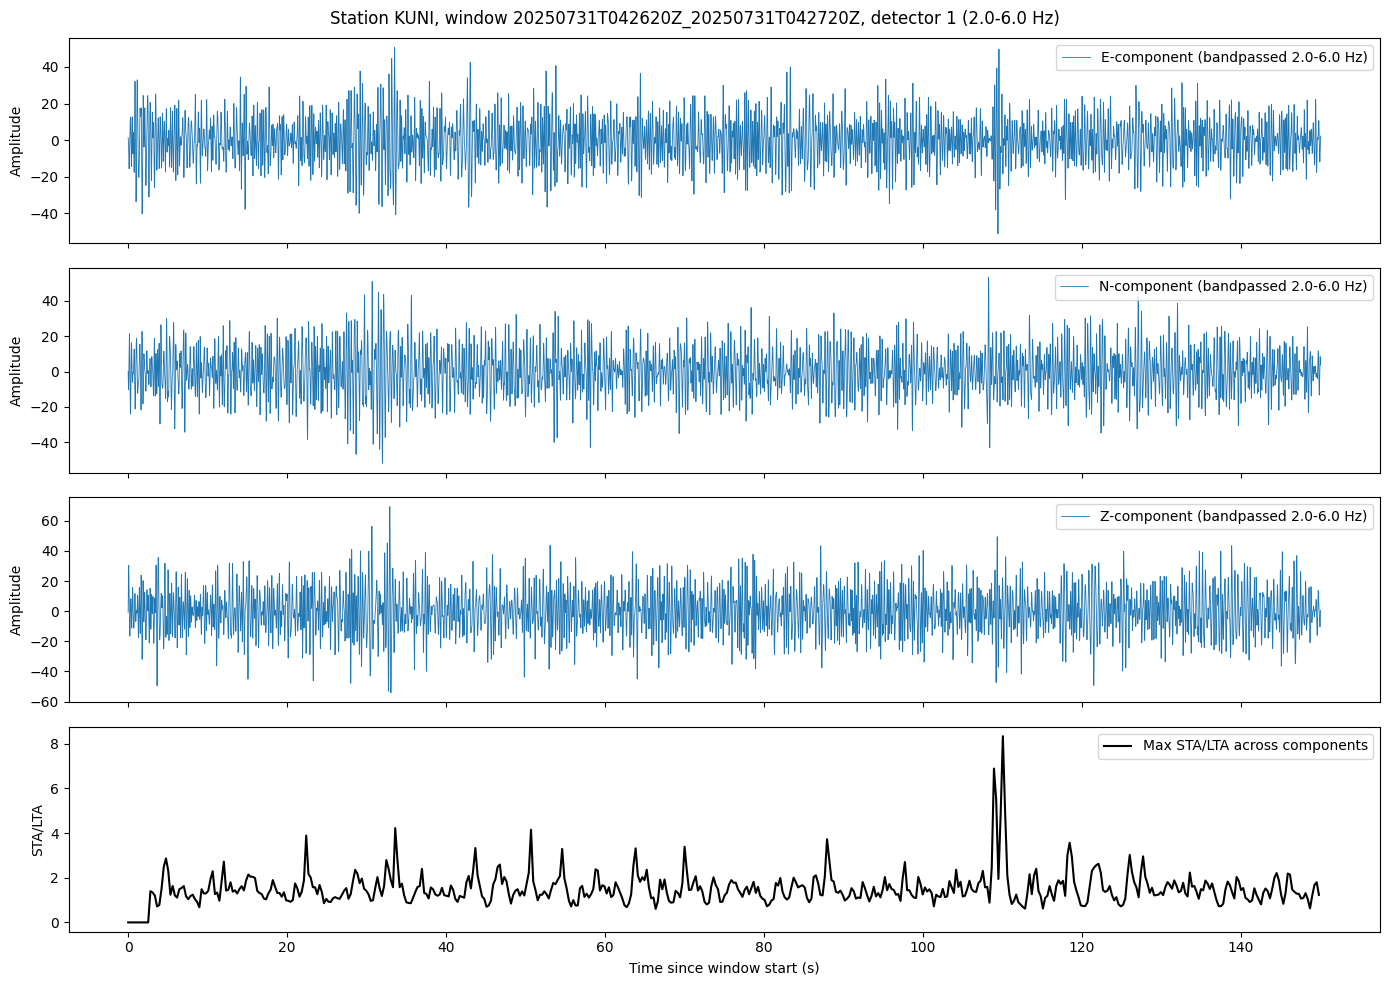

In [16]:
root = "waveforms_earthquakes_noise_only"
timestamp_dir = "20250731T042620Z_20250731T042720Z"
station = "KUNI"

plot_detections_for_station(root, timestamp_dir, station, detectors, fs=100.0, det_index=0)

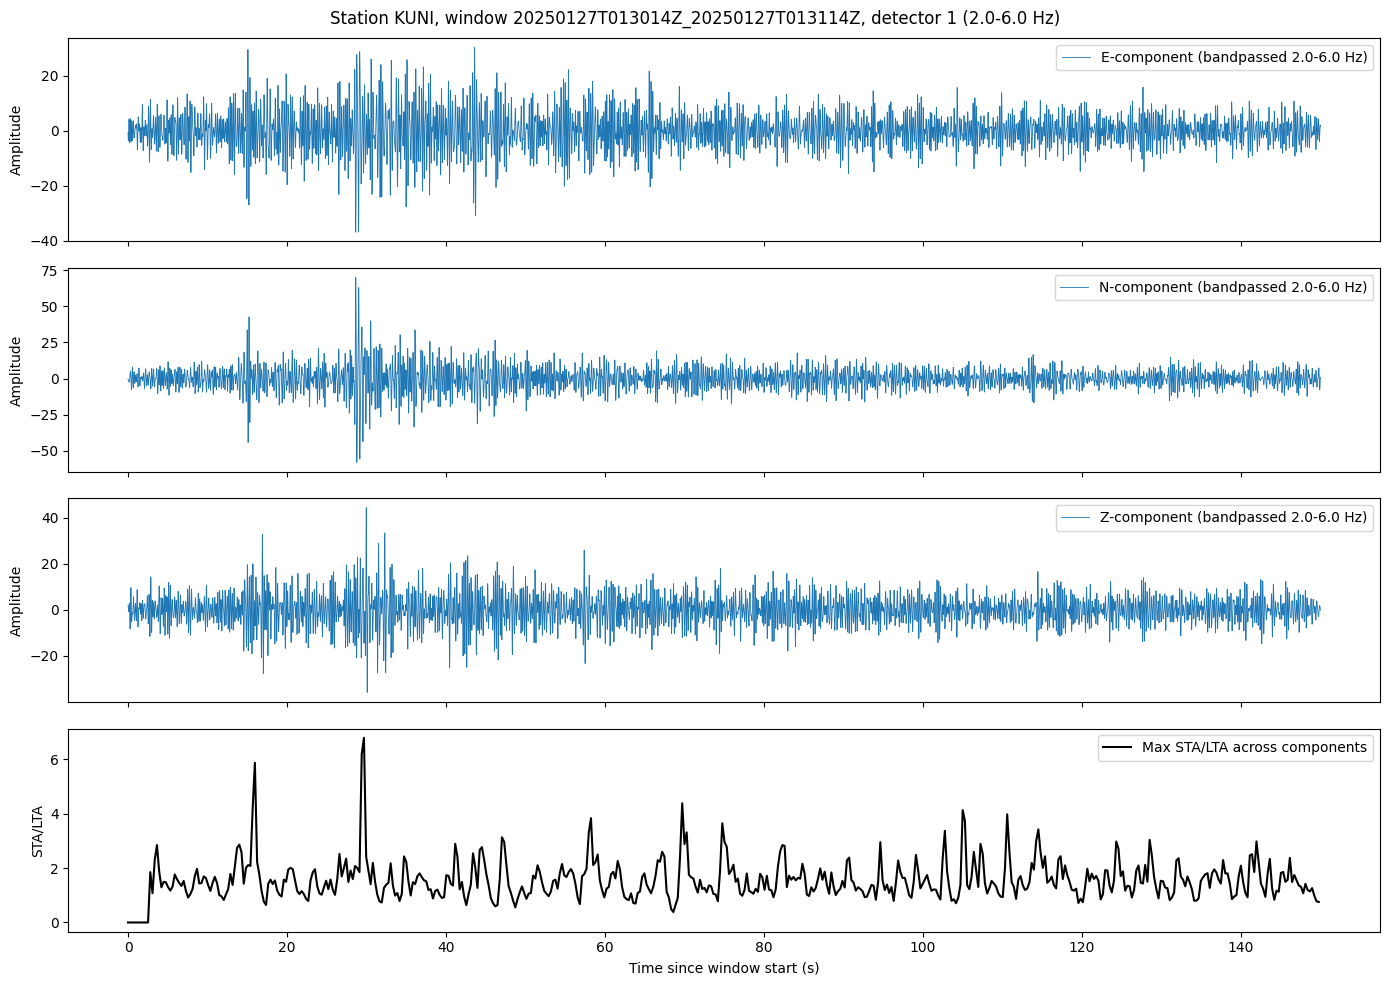

In [17]:
root = "waveforms_earthquakes_nonoise"
timestamp_dir = "20250127T013014Z_20250127T013114Z"
station = "KUNI"

# Choose detector 0–3
plot_detections_for_station(root, timestamp_dir, station, detectors, fs=100.0, det_index=0)